## Step 3

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [14]:
from src.data_prep import prepare_telco_data, print_split_summary, save_prepared_data

prepared = prepare_telco_data("../data/raw/telco_customer_churn.csv", random_state=42)
print_split_summary(prepared)

# Optional: persist prepared datasets for reuse
saved_files = save_prepared_data(prepared, output_dir="../data/processed")
print("Saved processed data files:")
for name, path in saved_files.items():
    print(f"- {name}: {path}")


Split shapes:
  Train: (4225, 20), y: (4225,)
  Val:   (1409, 20), y: (1409,)
  Test:  (1409, 20), y: (1409,)

Class distribution by split (0=No churn, 1=Churn):
Train:
       count  proportion
Churn                   
0       3104    0.734675
1       1121    0.265325
Val:
       count  proportion
Churn                   
0       1035    0.734564
1        374    0.265436
Test:
       count  proportion
Churn                   
0       1035    0.734564
1        374    0.265436

Transformed matrix shapes:
  Train processed: (4225, 45)
  Val processed:   (1409, 45)
  Test processed:  (1409, 45)
Saved processed data files:
- train_raw_with_target: /Users/bettylin/Documents/msin0097-predictive-analytics/data/processed/train_raw_with_target.csv
- val_raw_with_target: /Users/bettylin/Documents/msin0097-predictive-analytics/data/processed/val_raw_with_target.csv
- test_raw_with_target: /Users/bettylin/Documents/msin0097-predictive-analytics/data/processed/test_raw_with_target.csv
- X_train_proc

## Step 4

In [ ]:
from pathlib import Path
from src.data_prep import prepare_telco_data
from src.modeling import train_and_cv_models, save_comparison_table

# 1) Prepare data (preprocessor fit on train only in data_prep)
prepared = prepare_telco_data("../data/raw/telco_customer_churn.csv", random_state=42)
# 2) CV model comparison on TRAIN ONLY
comparison_df, raw_cv = train_and_cv_models(
    X_train_processed=prepared.X_train_processed,
    y_train=prepared.y_train,
    n_splits=5,
    random_state=42,
)

# 3) Show concise report table (mean ± std)
display_cols = [
    "model",
    "pr_auc_cv",
    "roc_auc_cv",
    "f1_cv",
    "recall_cv",
    "precision_cv",
    "balanced_accuracy_cv",
]
print(comparison_df[display_cols].to_string(index=False))

# 4) Save full results for report appendix/reproducibility
Path("../results").mkdir(parents=True, exist_ok=True)
save_comparison_table(comparison_df, "../results/step4/model_cv_comparison.csv")

                 model       pr_auc_cv      roc_auc_cv           f1_cv       recall_cv    precision_cv balanced_accuracy_cv
                logreg 0.6667 ± 0.0279 0.8475 ± 0.0119 0.5975 ± 0.0239 0.5540 ± 0.0321 0.6498 ± 0.0302      0.7229 ± 0.0156
       logreg_balanced 0.6654 ± 0.0285 0.8480 ± 0.0130 0.6343 ± 0.0195 0.8073 ± 0.0281 0.5227 ± 0.0206      0.7703 ± 0.0166
         random_forest 0.6533 ± 0.0060 0.8399 ± 0.0111 0.6062 ± 0.0214 0.6272 ± 0.0326 0.5873 ± 0.0224      0.7338 ± 0.0157
hist_gradient_boosting 0.6262 ± 0.0125 0.8251 ± 0.0131 0.5555 ± 0.0265 0.5157 ± 0.0428 0.6045 ± 0.0259      0.6966 ± 0.0166
   dummy_most_frequent 0.2653 ± 0.0005 0.5000 ± 0.0000 0.0000 ± 0.0000 0.0000 ± 0.0000 0.0000 ± 0.0000      0.5000 ± 0.0000


## Step 5

Best params: {'C': 0.1, 'class_weight': None}
Best CV PR-AUC: 0.6673


,params,mean_pr_auc,std_pr_auc
0,"{'C': 0.1, 'class_weight': None}",0.667267,0.023994
4,"{'C': 1, 'class_weight': None}",0.666700,0.024976
6,"{'C': 3, 'class_weight': None}",0.666588,0.025038
8,"{'C': 10, 'class_weight': None}",0.666557,0.025037
2,"{'C': 0.3, 'class_weight': None}",0.666481,0.024754


Best validation threshold: 0.36


,threshold,f1,recall,precision,balanced_accuracy
0,0.05,0.511628,0.970588,0.347368,0.655826
1,0.06,0.522182,0.959893,0.358641,0.669802
2,0.07,0.531157,0.957219,0.367556,0.681025
3,0.08,0.538695,0.949198,0.376059,0.690058
4,0.09,0.545879,0.938503,0.384868,0.698237


,pr_auc,roc_auc,f1,recall,precision,balanced_accuracy,brier_score,threshold
0,0.636301,0.841722,0.616307,0.687166,0.558696,0.745515,0.137448,0.36


Confusion matrix:
 [[832 203]
 [117 257]]
Figures saved in: /Users/bettylin/Documents/msin0097-predictive-analytics/reports/figures/02_modeling_fig2
Step 5 outputs saved to: /Users/bettylin/Documents/msin0097-predictive-analytics/results/step5


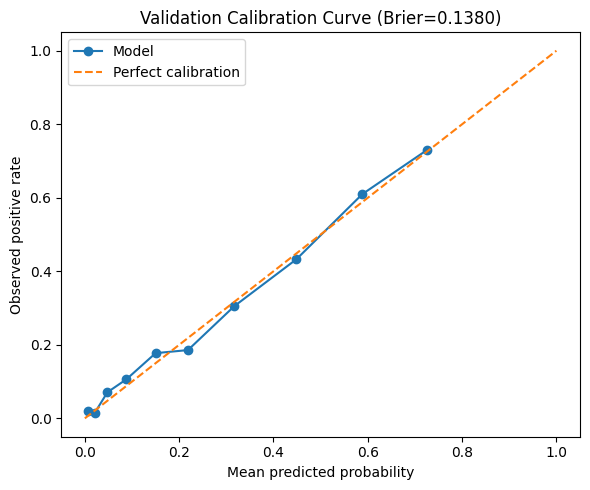

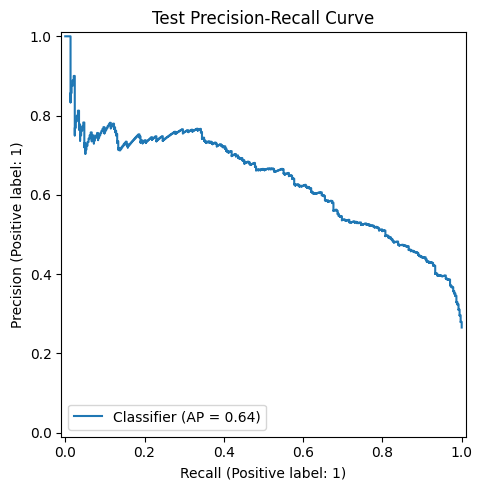

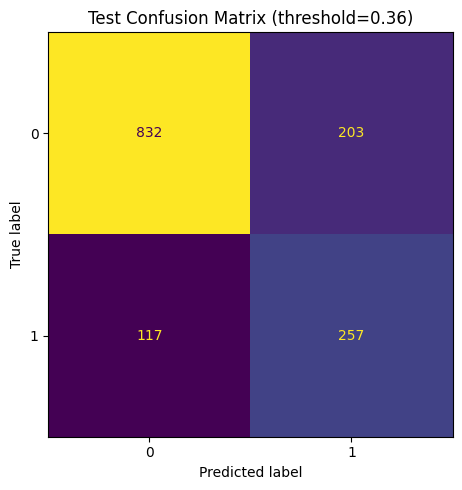

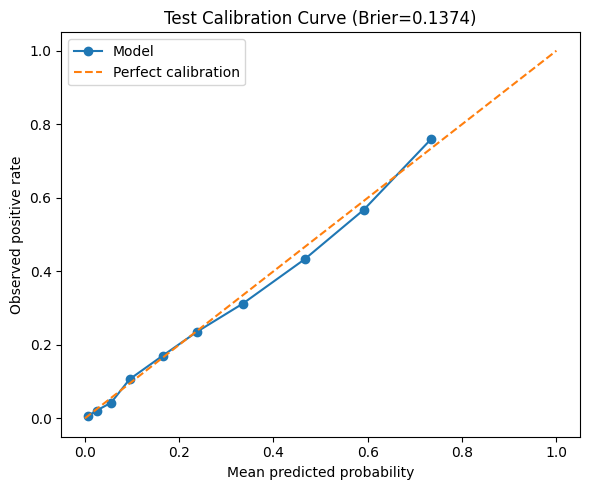

In [ ]:
from pathlib import Path
import json
from src.data_prep import prepare_telco_data
from src.evaluation import run_step5_evaluation

# Load prepared splits (no test leakage in tuning)
prepared = prepare_telco_data("../data/raw/telco_customer_churn.csv", random_state=42)

FIGURES_DIR = "../reports/figures/02_modeling_fig2"
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

results = run_step5_evaluation(
    prepared=prepared,
    threshold_objective="f1",          # or "constrained_precision"
    min_recall=0.75,                   # used only for constrained objective
    figures_dir=FIGURES_DIR,
    random_state=42,
)

# CV tuning summary
print("Best params:", results["tuning"].best_params)
print("Best CV PR-AUC:", round(results["tuning"].best_pr_auc, 4))
display(results["tuning"].cv_results[["params", "mean_pr_auc", "std_pr_auc"]].head())

# Threshold tuning summary
print("Best validation threshold:", results["threshold_result"].best_threshold)
display(results["threshold_result"].threshold_table.head())

# Final one-time test metrics
display(results["final_report_df"])
print("Confusion matrix:\n", results["test_metrics"]["confusion_matrix"])
print("Figures saved in:", results["figures_dir"])

# Save step 5 outputs to results/
RESULTS_DIR = Path("../results/step5")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results["final_report_df"].to_csv(RESULTS_DIR / "final_test_metrics_step5.csv", index=False)
results["tuning"].cv_results.to_csv(RESULTS_DIR / "tuning_cv_results.csv", index=False)
results["threshold_result"].threshold_table.to_csv(RESULTS_DIR / "validation_threshold_search.csv", index=False)

summary = {
    "best_params": results["tuning"].best_params,
    "best_cv_pr_auc": float(results["tuning"].best_pr_auc),
    "best_validation_threshold": float(results["threshold_result"].best_threshold),
    "test_metrics": {
        "pr_auc": float(results["test_metrics"]["pr_auc"]),
        "roc_auc": float(results["test_metrics"]["roc_auc"]),
        "f1": float(results["test_metrics"]["f1"]),
        "recall": float(results["test_metrics"]["recall"]),
        "precision": float(results["test_metrics"]["precision"]),
        "balanced_accuracy": float(results["test_metrics"]["balanced_accuracy"]),
        "brier_score": float(results["test_metrics"]["brier_score"]),
        "threshold": float(results["test_metrics"]["threshold"]),
        "confusion_matrix": results["test_metrics"]["confusion_matrix"].tolist(),
    },
    "figures_dir": results["figures_dir"],
}
(RESULTS_DIR / "step5_summary.json").write_text(json.dumps(summary, indent=2))

print(f"Step 5 outputs saved to: {RESULTS_DIR.resolve()}")

# Optional: keep report-level metrics file
Path("../reports").mkdir(parents=True, exist_ok=True)
results["final_report_df"].to_csv("../reports/final_test_metrics.csv", index=False)
